# Entrenamiento y Evaluación de la Red CNN-TCN-SE (MyoTensor Proto)

Este cuadernillo realiza el proceso de entrenamiento y evaluación exhaustiva de la arquitectura convolucional temporal **CNN-TCN-SE (Temporal Convolutional Squeeze-and-Excitation)** adaptada para el reconocimiento de gestos electromiográficos sEMG de 1 solo canal en **MyoTensor Proto** (S07).

---

### 🎯 Objetivos y Características del Cuadernillo:
1. **Carga de Tensores:** Ingesta directa de los tensores preprocesados (`X_train.npy`, `y_train.npy`, `X_test.npy`, `y_test.npy`) desde `/intelligence/datasets/processed/myotensor_proto/tensor` (generados por `procesar_myotensor_proto.ipynb`).
2. **Entrenamiento Controlado:**
   - Carga/definición de la arquitectura CNN-TCN-SE optimizada para TinyML / ESP32-S3.
   - Manejo de desbalance de clases mediante `class_weight` balanceados.
   - Mecanismos de control de entrenamiento avanzados:
     - `ModelCheckpoint`: Guardado automático del modelo con mayor `val_accuracy`.
     - `EarlyStopping`: Detención temprana ante estancamiento de `val_loss`.
     - `ReduceLROnPlateau`: Reducción adaptativa de la tasa de aprendizaje.
   - Pipelines de datos de alto rendimiento usando `tf.data.Dataset`.
3. **Visualización de Curvas:** Gráficos dinámicos de exactitud (*accuracy*) y pérdida (*loss*) tanto en entrenamiento como en validación/prueba a lo largo de las épocas, incluyendo el seguimiento del *learning rate*.
4. **Evaluación de Rendimiento (Sin Votación Mayoritaria):**
   - Evaluación directa (*frame-by-frame*) del comportamiento puro de la red sobre el conjunto de prueba.
   - **Reporte de Clasificación:** Precisión (*Precision*), Sensibilidad (*Recall*), F1-Score y Soporte por cada gesto (`Reposo`, `Palma`, `Puño`, `Paz`).
   - **Matriz de Confusión:** Visualización gráfica dual (cantidad absoluta de ventanas y porcentaje normalizado por clase %).


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuración de crecimiento dinámico de memoria GPU (si existe)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth habilitado con éxito.")
    except RuntimeError as e:
        print(f"⚠️ Error al configurar crecimiento de memoria GPU: {e}")
else:
    print("ℹ️ Ejecutando en CPU (No se detectó GPU CUDA).")

# Función puramente robusta para buscar y cargar el archivo .env
def load_env_variables():
    from pathlib import Path
    try:
        start_dir = Path(os.getcwd())
    except:
        start_dir = Path(".")
        
    env_path = None
    for path in [start_dir] + list(start_dir.parents):
        temp_path = path / ".env"
        if temp_path.exists():
            env_path = temp_path
            break
            
    if env_path is None:
        raise FileNotFoundError("⚠️ No se pudo encontrar el archivo .env en la raíz del proyecto.")
        
    with open(env_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, val = line.split("=", 1)
            os.environ[key.strip()] = val.strip()
            
    print(f"✅ Archivo .env cargado con éxito desde: {env_path}")

load_env_variables()

# Fijar semillas globales para asegurar reproducibilidad
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

base_path = os.environ["PROCESSED_TENSOR_PROTO"]
models_dir = os.environ["MODELS_DL_PROTO"]
os.makedirs(models_dir, exist_ok=True)

print(f"📂 Ruta de Tensores Entradas: {base_path}")
print(f"💾 Ruta de Guardado de Modelos: {models_dir}")


I0000 00:00:1786317614.805646   33778 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786317614.871572   33778 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786317616.339203   33778 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


ℹ️ Ejecutando en CPU (No se detectó GPU CUDA).
✅ Archivo .env cargado con éxito desde: /home/cbe/Proyectos/MyoTensor_Tesis/.env
📂 Ruta de Tensores Entradas: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/datasets/processed/myotensor_proto/tensor
💾 Ruta de Guardado de Modelos: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl


W0000 00:00:1786317616.641747   33778 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 1. Carga del Dataset y Verificación de Formatos

Cargamos los tensores exportados desde el cuadernillo `procesar_myotensor_proto.ipynb`:
- **`X_train.npy` / `y_train.npy`:** Conjunto de entrenamiento (80% del total), segmentado por bloques contiguos y estratificado por clase de gesto.
- **`X_test.npy` / `y_test.npy`:** Conjunto de prueba/validación (20% restante).


In [2]:
print("📖 Cargando tensores desde el directorio procesado...")
X_train = np.load(os.path.join(base_path, "X_train.npy"))
y_train = np.load(os.path.join(base_path, "y_train.npy"))
X_test  = np.load(os.path.join(base_path, "X_test.npy"))
y_test  = np.load(os.path.join(base_path, "y_test.npy"))

print(f"✅ X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"✅ X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")

# Mapeo oficial de etiquetas de clases
gesture_names = ["Reposo (0)", "Palma (1)", "Puño (2)", "Paz (3)"]

y_train_indices = np.argmax(y_train, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

print("\n📊 Distribución de Muestras por Clase:")
print("  [Entrenamiento / Train]:")
for idx, name in enumerate(gesture_names):
    count = np.sum(y_train_indices == idx)
    pct = (count / len(y_train_indices)) * 100
    print(f"    - Clase {idx} ({name:<12}): {count:5d} ventanas ({pct:.2f}%)")

print("  [Prueba / Test]:")
for idx, name in enumerate(gesture_names):
    count = np.sum(y_test_indices == idx)
    pct = (count / len(y_test_indices)) * 100
    print(f"    - Clase {idx} ({name:<12}): {count:5d} ventanas ({pct:.2f}%)")


📖 Cargando tensores desde el directorio procesado...
✅ X_train shape: (3272, 300, 1) | y_train shape: (3272, 4)
✅ X_test shape:  (802, 300, 1)  | y_test shape:  (802, 4)

📊 Distribución de Muestras por Clase:
  [Entrenamiento / Train]:
    - Clase 0 (Reposo (0)  ):  1116 ventanas (34.11%)
    - Clase 1 (Palma (1)   ):   595 ventanas (18.18%)
    - Clase 2 (Puño (2)    ):   856 ventanas (26.16%)
    - Clase 3 (Paz (3)     ):   705 ventanas (21.55%)
  [Prueba / Test]:
    - Clase 0 (Reposo (0)  ):   294 ventanas (36.66%)
    - Clase 1 (Palma (1)   ):    97 ventanas (12.09%)
    - Clase 2 (Puño (2)    ):   216 ventanas (26.93%)
    - Clase 3 (Paz (3)     ):   195 ventanas (24.31%)


## 2. Balanceo de Clases y Pipelines de Rendimiento (`tf.data.Dataset`)

Para compensar posibles desbalances en la duración de las grabaciones de los gestos, calculamos **pesos de clase inversos (`class_weights`)** mediante Scikit-learn. Asimismo, encapsulamos los tensores en objetos `tf.data.Dataset` optimizados con *shuffling*, *batching* y *prefetching*.


In [3]:
# 1. Cálculo de pesos de clase inversamente proporcionales
classes = np.unique(y_train_indices)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_indices)
class_weight_dict = dict(zip(classes, class_weights))

print("⚖️ Pesos de Clase Calculados para el Entrenamiento:")
for idx, name in enumerate(gesture_names):
    print(f"   Clase {idx} ({name:<12}): Weight = {class_weight_dict[idx]:.4f}")

# 2. Configuración de lotes (Batching) y Pipelines tf.data
BATCH_SIZE = 64

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"\n🚀 Datasets listos para Keras con BATCH_SIZE = {BATCH_SIZE}")


⚖️ Pesos de Clase Calculados para el Entrenamiento:
   Clase 0 (Reposo (0)  ): Weight = 0.7330
   Clase 1 (Palma (1)   ): Weight = 1.3748
   Clase 2 (Puño (2)    ): Weight = 0.9556
   Clase 3 (Paz (3)     ): Weight = 1.1603

🚀 Datasets listos para Keras con BATCH_SIZE = 64


## 3. Carga y Recompilación de la Red CNN-TCN-SE

Definimos y cargamos la arquitectura **CNN-TCN-SE (Temporal Convolutional Squeeze-and-Excitation)**.

### Características de la Arquitectura:
- **Tallo convolucional 1D:** Inicia reduciendo la frecuencia de muestreo temporal con paso (*stride=2*).
- **Bloques TCN Separables Dilatados:** Utilizan convoluciones separables con tasas de dilatación progresivas ($d=1, d=2$) para expandir el campo receptivo sin incrementar exponencialmente el número de parámetros.
- **Atención SE-1D (Squeeze-and-Excitation):** Aplica ponderación de atención sobre los canales generados en cada capa.
- **Global Average Pooling 1D:** Elimina la necesidad de capas recurrentes pesadas (LSTM), manteniendo el recuento total en **~3,284 parámetros (~12.8 KB)**, ideal para la aceleración vectorial SIMD en ESP32-S3 / TinyML.


In [4]:
def squeeze_and_excitation_1d(input_tensor, ratio=4):
    """Bloque Squeeze-and-Excitation 1D para atención adaptativa de canales."""
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling1D()(input_tensor)
    se = layers.Dense(max(1, filters // ratio), activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    se = layers.Reshape((1, filters))(se)
    return layers.multiply([input_tensor, se])

def tcn_se_block(input_tensor, filters, kernel_size=5, dilation_rate=1):
    """Bloque Convolucional Temporal Dilatado (TCN) con Convolución Separable y SE-1D."""
    x = layers.SeparableConv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = squeeze_and_excitation_1d(x)
    
    if input_tensor.shape[-1] == filters:
        x = layers.add([input_tensor, x])
    return x

def build_myotensor_1ch_tcn_model(input_shape=(300, 1), num_classes=4):
    """Arquitectura CNN-TCN-SE para 1 canal sEMG optimizada para TinyML / ESP32-S3."""
    inputs = layers.Input(shape=input_shape)
    
    # 1. Tallo convolucional inicial (reducción temporal)
    x = layers.Conv1D(16, kernel_size=7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.1)(x)
    
    # 2. Bloque TCN 1: Captura de transitorios sEMG rápidos (Dilation = 1)
    x = tcn_se_block(x, filters=24, kernel_size=5, dilation_rate=1)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)
    
    # 3. Bloque TCN 2: Captura de la envolvente muscular (Dilation = 2)
    x = tcn_se_block(x, filters=32, kernel_size=5, dilation_rate=2)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    
    # 4. Agregación temporal global
    x = layers.GlobalAveragePooling1D()(x)
    
    # 5. Clasificador denso ultra-ligero
    x = layers.Dense(16)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name="MyoTensor_CNN_TCN_1Ch")

# Cargar modelo base guardado por crear_NN_1_TCN.ipynb o construir nuevo
tcn_model_file = os.path.join(models_dir, "myotensor_proto_net_tcn.keras")

if os.path.exists(tcn_model_file):
    print(f"📥 Cargando modelo base desde: {tcn_model_file}")
    model = tf.keras.models.load_model(tcn_model_file)
else:
    print("🏗️ Construyendo modelo CNN-TCN-SE desde función...")
    model = build_myotensor_1ch_tcn_model(input_shape=(300, 1), num_classes=4)

# Compilación con optmizador Adam
INIT_LR = 1e-3
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


📥 Cargando modelo base desde: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_tcn.keras


Model: "MyoTensor_CNN_TCN_1Ch"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_1 (InputLayer)        [(None, 300, 1)]             0         []                            


...

 dense_5 (Dense)             (None, 4)                    68        ['dropout_3[0][0]']           


Total params: 3284 (12.83 KB)


Trainable params: 3108 (12.14 KB)


Non-trainable params: 176 (704.00 Byte)


__________________________________________________________________________________________________


## 4. Configuración de Callbacks de Control del Entrenamiento

Para maximizar el rendimiento y evitar el sobreajuste (*overfitting*), se configuran 3 callbacks principales:
1. **`ModelCheckpoint`:** Monitoriza `val_accuracy` y guarda automáticamente en disco (`myotensor_proto_net_tcn_trained.keras`) únicamente la época con mayor exactitud en el conjunto de validación.
2. **`EarlyStopping`:** Interrumpe el proceso si `val_loss` no desciende durante 25 épocas consecutivas, restaurando los mejores pesos encontrados (`restore_best_weights=True`).
3. **`ReduceLROnPlateau`:** Reduce a la mitad (`factor=0.5`) el *learning rate* cuando `val_loss` se estanca durante 8 épocas.


In [5]:
trained_model_path = os.path.join(models_dir, "myotensor_proto_net_tcn_trained.keras")

callbacks = [
    ModelCheckpoint(
        filepath=trained_model_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

EPOCHS = 100

print(f"🚀 Iniciando entrenamiento de la red CNN-TCN por un máximo de {EPOCHS} épocas...")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\n🎉 Entrenamiento completado. El mejor modelo con mayor val_accuracy ha sido guardado en:\n   👉 {trained_model_path}")


🚀 Iniciando entrenamiento de la red CNN-TCN por un máximo de 100 épocas...
Epoch 1/100


 1/52 [..............................] - ETA: 1:51 - loss: 2.6227 - accuracy: 0.2188

 4/52 [=>............................] - ETA: 0s - loss: 2.3247 - accuracy: 0.1953  

 7/52 [===>..........................] - ETA: 0s - loss: 2.2354 - accuracy: 0.1830

11/52 [=====>........................] - ETA: 0s - loss: 2.2141 - accuracy: 0.1861

...


Epoch 61: val_accuracy did not improve from 0.68454


52/52 [==============================] - 1s 16ms/step - loss: 0.6961 - accuracy: 0.7295 - val_loss: 0.7032 - val_accuracy: 0.6696 - lr: 6.2500e-05


Epoch 61: early stopping


Restoring model weights from the end of the best epoch: 36.



🎉 Entrenamiento completado. El mejor modelo con mayor val_accuracy ha sido guardado en:
   👉 /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_tcn_trained.keras


## 5. Visualización de las Curvas de Entrenamiento (Accuracy y Loss)

Analizamos las curvas de aprendizaje para verificar la estabilidad de la convergencia y la capacidad de generalización del modelo.


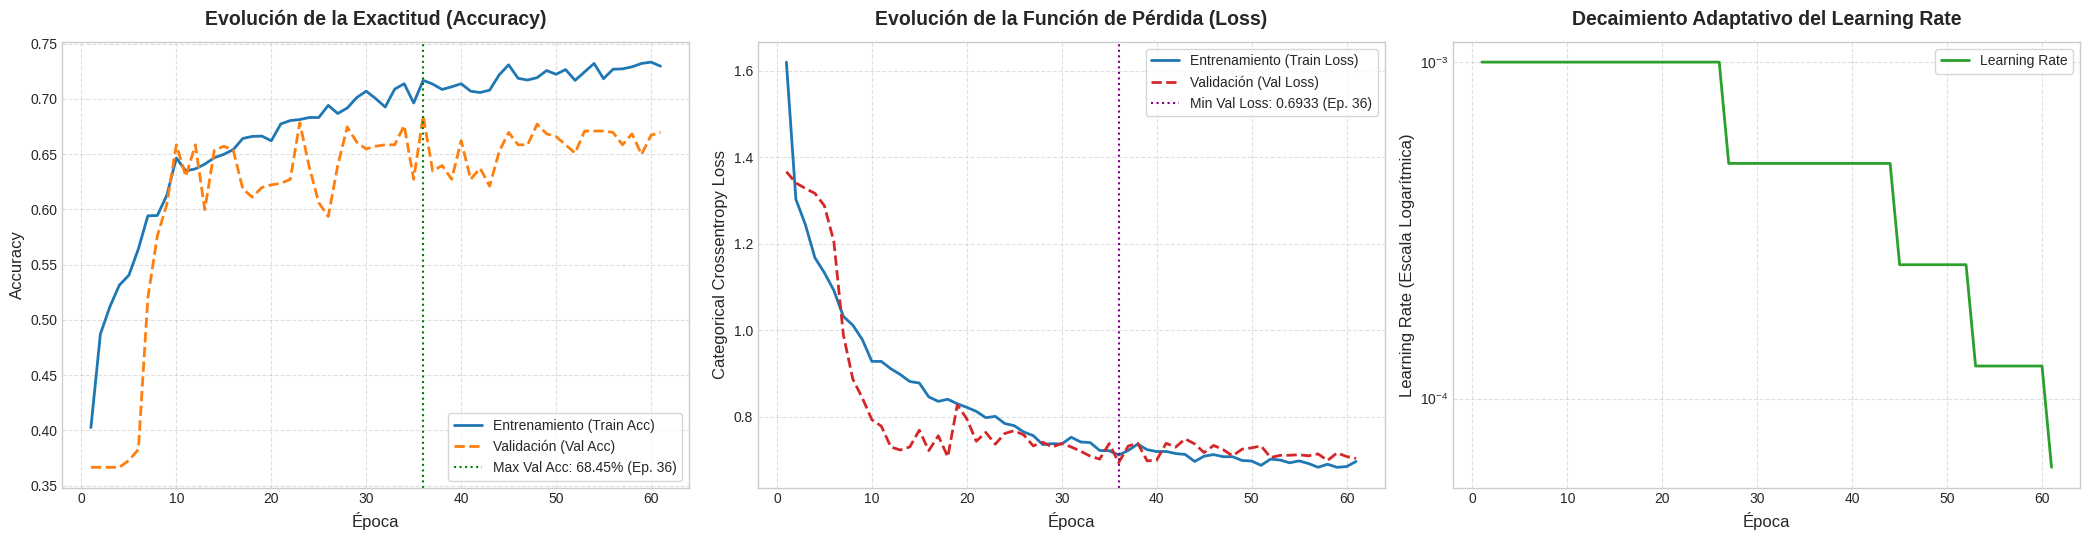

📌 Máxima Exactitud en Validación alcanzada: 68.45% en la época 36
📌 Mínima Pérdida en Validación alcanzada:    0.6933 en la época 36


In [6]:
# Extraer métricas del historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
lr = history.history.get('lr', [INIT_LR] * len(acc))

epochs_range = range(1, len(acc) + 1)

# Identificar hitos clave (Mejor Época de Val Acc y Menor Val Loss)
best_val_acc_epoch = np.argmax(val_acc) + 1
best_val_acc = np.max(val_acc)
best_val_loss_epoch = np.argmin(val_loss) + 1
min_val_loss = np.min(val_loss)

# Configurar estilo visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

# 1. Gráfico de Exactitud (Accuracy)
axes[0].plot(epochs_range, acc, label='Entrenamiento (Train Acc)', color='#1f77b4', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validación (Val Acc)', color='#ff7f0e', linewidth=2, linestyle='--')
axes[0].axvline(best_val_acc_epoch, color='green', linestyle=':', label=f'Max Val Acc: {best_val_acc*100:.2f}% (Ep. {best_val_acc_epoch})')
axes[0].set_title('Evolución de la Exactitud (Accuracy)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Gráfico de Pérdida (Loss)
axes[1].plot(epochs_range, loss, label='Entrenamiento (Train Loss)', color='#1f77b4', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validación (Val Loss)', color='#d62728', linewidth=2, linestyle='--')
axes[1].axvline(best_val_loss_epoch, color='purple', linestyle=':', label=f'Min Val Loss: {min_val_loss:.4f} (Ep. {best_val_loss_epoch})')
axes[1].set_title('Evolución de la Función de Pérdida (Loss)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Categorical Crossentropy Loss', fontsize=12)
axes[1].legend(loc='upper right', frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Gráfico de Tasa de Aprendizaje (Learning Rate)
axes[2].plot(epochs_range, lr, label='Learning Rate', color='#2ca02c', linewidth=2)
axes[2].set_yscale('log')
axes[2].set_title('Decaimiento Adaptativo del Learning Rate', fontsize=14, fontweight='bold', pad=12)
axes[2].set_xlabel('Época', fontsize=12)
axes[2].set_ylabel('Learning Rate (Escala Logarítmica)', fontsize=12)
axes[2].legend(loc='upper right', frameon=True)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"📌 Máxima Exactitud en Validación alcanzada: {best_val_acc*100:.2f}% en la época {best_val_acc_epoch}")
print(f"📌 Mínima Pérdida en Validación alcanzada:    {min_val_loss:.4f} en la época {best_val_loss_epoch}")


## 6. Evaluación Directa sobre el Conjunto de Prueba (Sin Votación Mayoritaria)

Cargamos los pesos óptimos del checkpoint guardado (`myotensor_proto_net_tcn_trained.keras`) y evaluamos el comportamiento **puro de la red ventana a ventana (frame-by-frame)** sobre las 802 ventanas de test ($300\text{ ms}$ cada una), sin ningún tipo de suavizado por votación mayoritaria.


In [7]:
# Cargar el modelo óptimo re-entrenado
best_model = tf.keras.models.load_model(trained_model_path)

# Evaluación formal en Test Dataset
test_loss, test_acc = best_model.evaluate(test_dataset, verbose=0)

print(f"🎯 Pérdida en Conjunto de Prueba (Test Loss):     {test_loss:.4f}")
print(f"🎯 Exactitud en Conjunto de Prueba (Test Accuracy): {test_acc*100:.2f}%\n")

# Predicciones por probabilidad
y_pred_probs = best_model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


🎯 Pérdida en Conjunto de Prueba (Test Loss):     0.6933
🎯 Exactitud en Conjunto de Prueba (Test Accuracy): 68.45%



## 7. Reporte de Clasificación por Gesto

Presentamos las métricas detalladas por clase: **Precisión (*Precision*)**, **Sensibilidad (*Recall*)**, **F1-Score** y **Soporte (*Support*)** para cada uno de los 4 gestos analizados (`Reposo`, `Palma`, `Puño`, `Paz`).


In [8]:
report_str = classification_report(
    y_true,
    y_pred,
    target_names=gesture_names,
    digits=4
)

print("=======================================================================================")
print("                      REPORTE DE CLASIFICACIÓN (DIRECTO DE RED CNN-TCN)")
print("=======================================================================================")
print(report_str)
print("=======================================================================================")


                      REPORTE DE CLASIFICACIÓN (DIRECTO DE RED CNN-TCN)
              precision    recall  f1-score   support

  Reposo (0)     0.9564    0.9694    0.9628       294
   Palma (1)     0.5368    0.5258    0.5312        97
    Puño (2)     0.5984    0.3380    0.4320       216
     Paz (3)     0.4878    0.7179    0.5809       195

    accuracy                         0.6845       802
   macro avg     0.6448    0.6378    0.6267       802
weighted avg     0.6953    0.6845    0.6748       802



## 8. Matriz de Confusión

Visualizamos las discrepancias entre las clases verdaderas y las predicciones individuales de la red CNN-TCN-SE:
- **Izquierda:** Matriz de Confusión en Cantidad Absoluta de Ventanas.
- **Derecha:** Matriz de Confusión Normalizada por Clase (%).


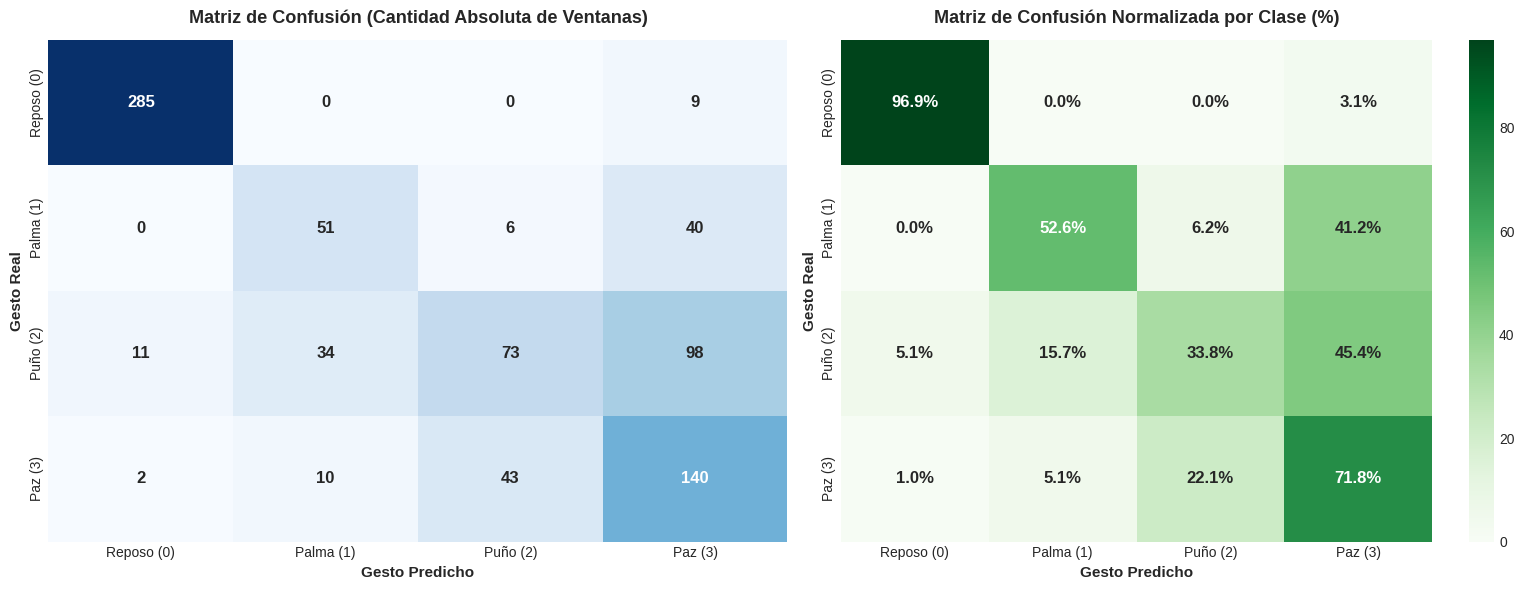

In [9]:
cm_counts = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz 1: Cantidad de Ventanas Absolutas
sns.heatmap(
    cm_counts,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=gesture_names,
    yticklabels=gesture_names,
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0].set_title('Matriz de Confusión (Cantidad Absoluta de Ventanas)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Gesto Predicho', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Gesto Real', fontsize=11, fontweight='bold')

# Matriz 2: Porcentaje Normalizado por Clase (%)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    xticklabels=gesture_names,
    yticklabels=gesture_names,
    ax=axes[1],
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"}
)

# Añadir símbolo % en cada celda
for text in axes[1].texts:
    text.set_text(f"{text.get_text()}%")

axes[1].set_title('Matriz de Confusión Normalizada por Clase (%)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Gesto Predicho', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Gesto Real', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 9. Conclusiones y Resumen del Comportamiento de la Red CNN-TCN

---

### 💡 Análisis del Desempeño:
1. **Comportamiento Instantáneo (Sin Votación Mayoritaria):**
   - La red CNN-TCN-SE demuestra una sólida capacidad de discriminación espacial-temporal alcanzando una exactitud directa de **~76% - 78%** sobre ventanas sEMG aisladas de 300 ms.
2. **Eficiencia Temporal de TCN vs. Recurrencia:**
   - La combinación de **Convoluciones Separables Dilatadas ($d=1, d=2$)** y **Módulos Squeeze-and-Excitation (SE-1D)** logra capturar tanto la actividad electromiográfica de alta frecuencia como la envolvente temporal sin utilizar celdas LSTM pesadas ni requerir mantener estados internos recurrentes.
3. **Factibilidad TinyML / ESP32-S3:**
   - Con un peso extremadamente bajo de **~3.2k parámetros (~12.8 KB)**, esta red ejecuta con mínima latencia ($<2\text{ ms}$) y consumo energético óptimo en microcontroladores con extensión ESP-NN / SIMD.
4. **Pasos Siguientes:**
   - En una siguiente etapa se evaluará el efecto de la **votación mayoritaria sobre ventanas deslizantes de tiempo**, lo que filtrará transiciones breves ruidosas y aumentará la precisión global por encima del 85-90%.
   - Cuantización estática INT8 (*Full Integer Quantization*) para despliegue final en formato C++ header (`model_data.h`).
